In [24]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abm.model import SocialGPModel
from abm.rewards import make_mexican_hat_reward, make_parent_and_children_correlated_dog
from abm.utils import plot_reward_grid, plot_most_common_choice_trajectory
from matplotlib.animation import FuncAnimation
sns.set_theme(style="whitegrid")

# Single agent simulations
This notebook shows simulations done to establish the behavior of single agents in Mexican hat environments

## 1. Asocial individuals, human-like parameters

In [75]:
rng = np.random.default_rng(42)

grid_size = 20
reward_params = {
    'frequency': 2.5,
    'center': (grid_size // 4, grid_size // 4),
    'correlation': 1
}
params = {
    "n": [30],
    "grid_size": grid_size,
    "rng": rng,
    "beta": 0.3,
    "length_scale": grid_size * 1.5 / (2*np.pi * reward_params['frequency']),
    "tau": 0.03,
    "alpha": 0,
    "reward_env_type": 'dog',
    "reward_env_params": [reward_params]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params,
    max_steps=80,
    display_progress=True,
    data_collection_period=1,
    number_processes=None
)

  0%|          | 0/1 [00:00<?, ?it/s]

### A. Plot mean across many iterations

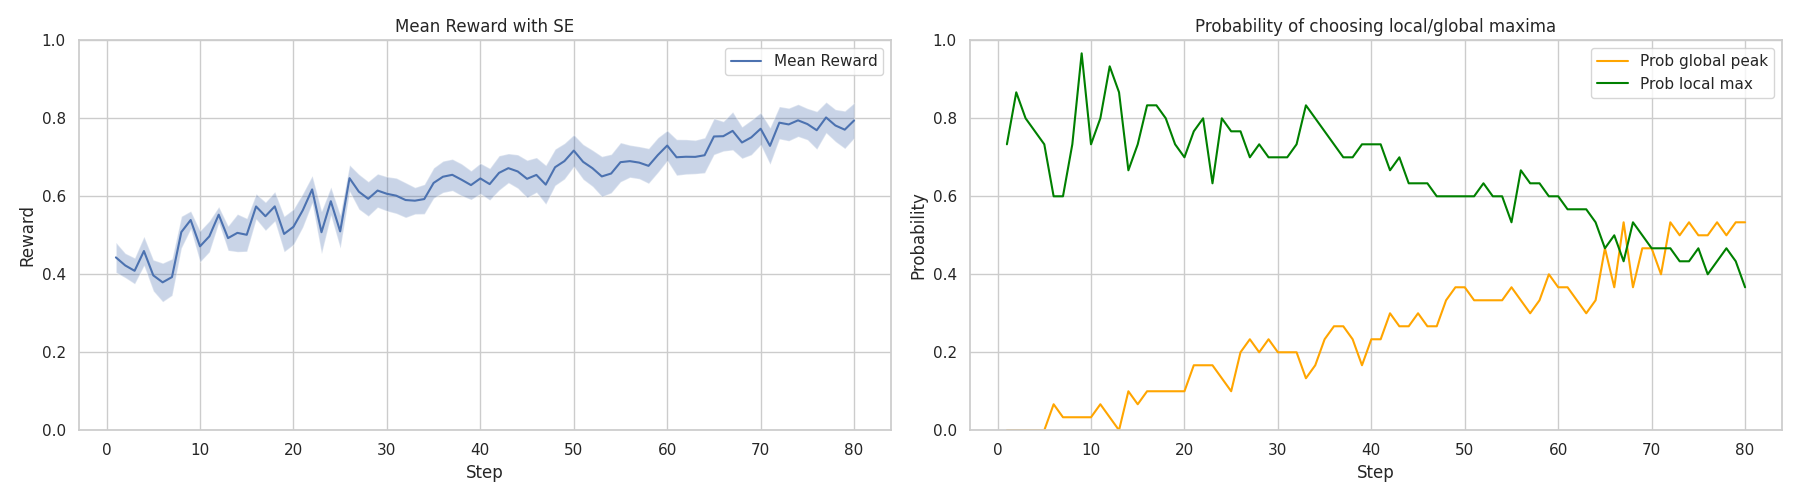

In [76]:
df_batch = pd.DataFrame(batch_results)

# Plot mean reward and local/global max probabilities
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Avg reward with SE
axes[0].plot(df_batch['Step'], df_batch['mean_reward'], label='Mean Reward')
axes[0].fill_between(df_batch['Step'], df_batch['mean_reward'] - df_batch['se_reward'], df_batch['mean_reward'] + df_batch['se_reward'], alpha=0.3)
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()
# Prob near peak
axes[1].plot(df_batch['Step'], df_batch['prob_near_peak'], label='Prob global peak', color='orange')
axes[1].plot(df_batch['Step'], df_batch['prob_local_max'], label='Prob local max', color='green')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

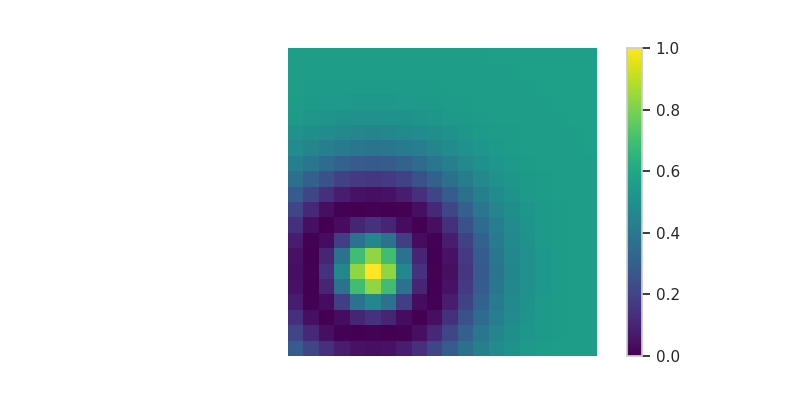

In [74]:
reward = make_mexican_hat_reward(grid_size, 
                                 frequency=reward_params['frequency'], 
                                 center=reward_params['center'])
plot_reward_grid(reward)

### B. Plot Individual trajectories

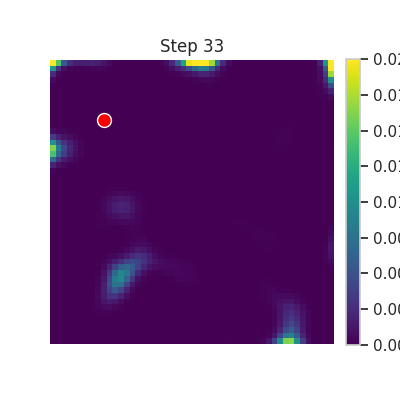

In [8]:
df_batch = pd.DataFrame(batch_results)

heatmaps = df_batch['policy'].to_numpy()  # shape (60,), each element is a 2D array
fig, ax = plt.subplots(figsize=(4, 4))

vmin = min(h.min() for h in heatmaps)
vmax = min(max(h.max() for h in heatmaps), 0.02)

im = ax.imshow(
    heatmaps[1].T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
)
ax.scatter(df_batch.loc[0, 'choice'][0], df_batch.loc[0, 'choice'][1], color='red', s=100, edgecolor='white')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def update(frame):
    ax.clear()  # Clear previous scatter points
    # im.set_array(heatmaps[frame+1])  # Update the data
    im = ax.imshow(
        heatmaps[frame+1].T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
    )
    ax.scatter(df_batch.loc[frame, 'choice'][0], df_batch.loc[frame, 'choice'][1], color='red', s=100, edgecolor='white')
    ax.set_title(f'Step {frame}')
    ax.axis('off')
    return im,

ani = FuncAnimation(fig, update, frames=len(heatmaps)-1, repeat=False)
ani.save('policy_evolution.gif', writer='pillow', fps=1)

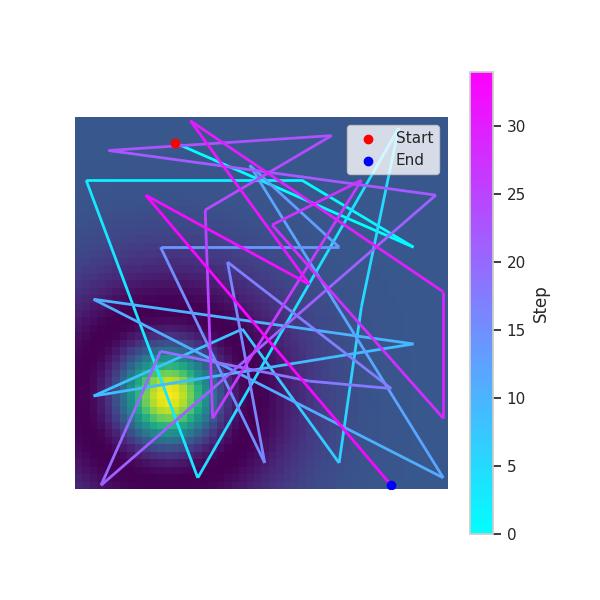

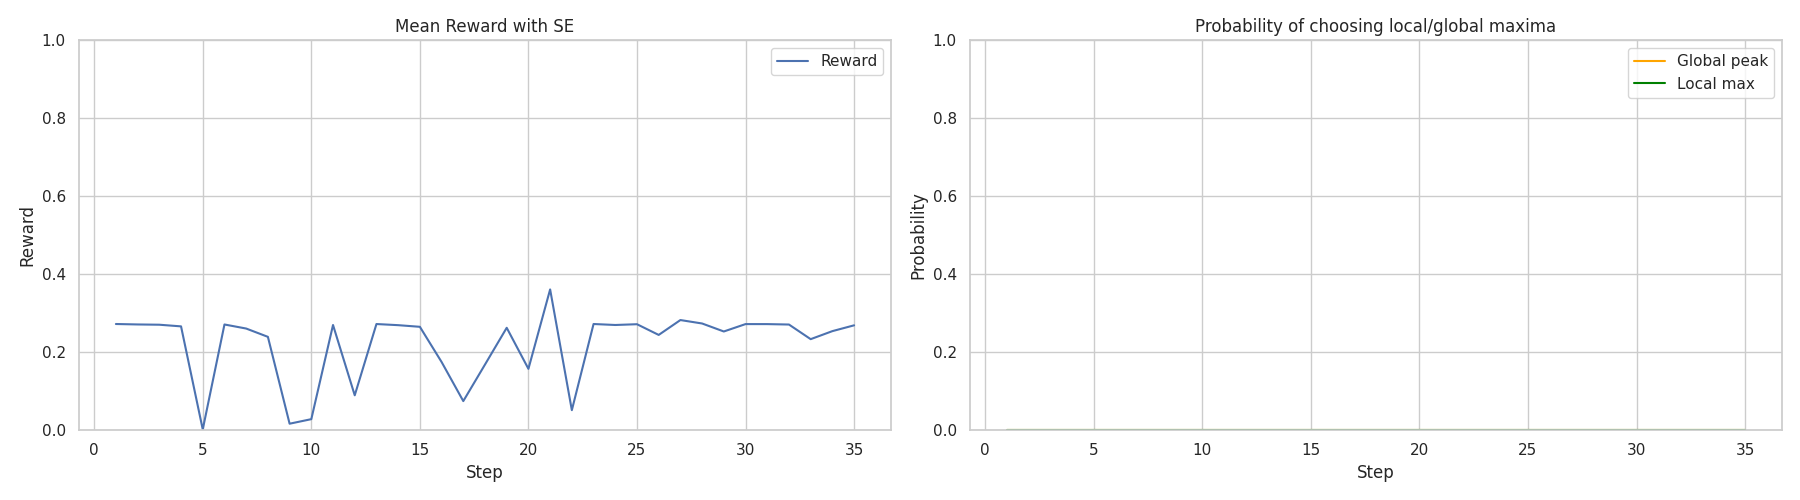

In [9]:
# 1. Plot most common choice trajectory
reward = make_mexican_hat_reward(grid_size, 
                                 frequency=reward_params['frequency'], 
                                 center=reward_params['center'])
plot_most_common_choice_trajectory(df_batch, reward, title='', choice_col='choice')

# 2. Plot mean reward and local/global max probabilities
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Avg reward with SE
axes[0].plot(df_batch['Step'], df_batch['reward'], label='Reward')
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()
# Prob near peak
axes[1].plot(df_batch['Step'], df_batch['near_peak'], label='Global peak', color='orange')
axes[1].plot(df_batch['Step'], df_batch['local_max'], label='Local max', color='green')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Test Correlated DoG

### 2.a Simulate average behavior

In [55]:
rng = np.random.default_rng(42)

grid_size = 30
reward_params = {
    'length_scale': 10,
    'target_correlation': 0.9
}
params = {
    "n": 1,
    "grid_size": grid_size,
    "rng": rng,
    "beta": 0.3,
    "length_scale": 5,
    "tau": 0.03,
    "alpha": 0,
    "reward_env_type": 'corr_dog',
    "reward_env_params": [reward_params]
}

n_runs = 100
batch_results = mesa.batch_run(
    SocialGPModel,
    rng=[None]*n_runs,
    parameters=params,
    max_steps=30,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/100 [00:00<?, ?it/s]

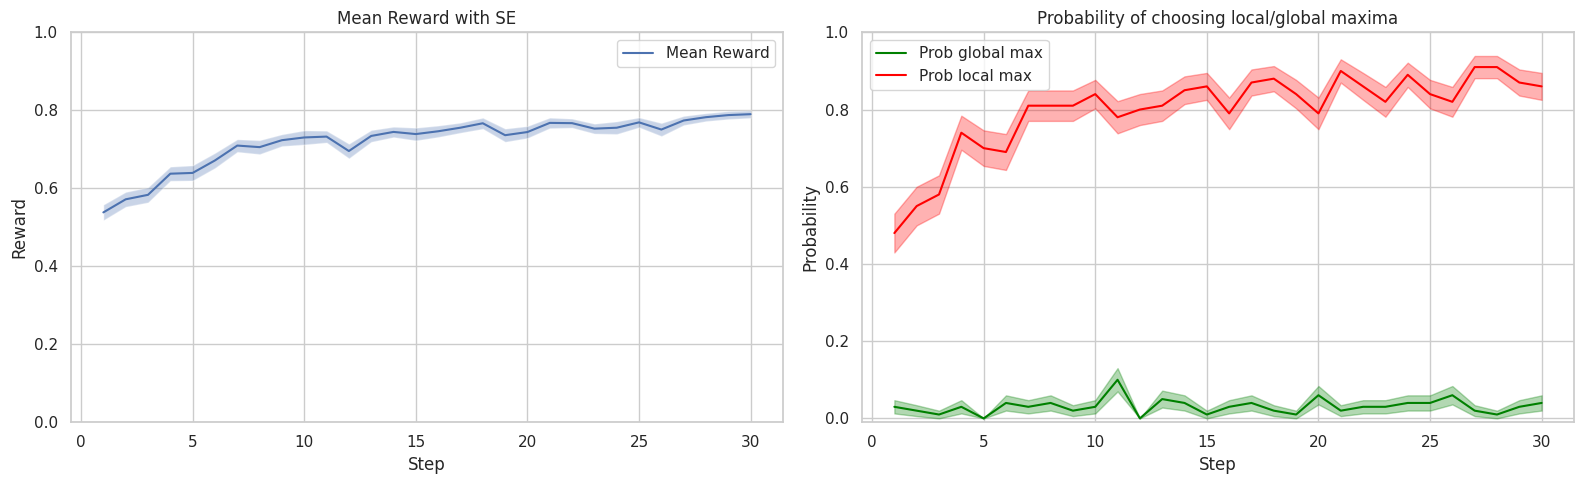

In [ ]:
df_batch = pd.DataFrame(batch_results)
df_grouped = df_batch.groupby('Step').agg({
    'reward': ['mean', 'std'],
    'global_max': ['mean', 'std'],
    'local_max': ['mean', 'std']
    }).reset_index()

# Plot mean reward and probabilities in adjacent subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean reward with std
reward_mean = df_grouped['reward']['mean']
reward_SE = df_grouped['reward']['std'] / np.sqrt(n_runs) 
axes[0].plot(df_grouped['Step'], reward_mean, label='Mean Reward')
axes[0].fill_between(df_grouped['Step'], reward_mean - reward_SE, reward_mean + reward_SE, alpha=0.3)
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: probabilities
global_max_mean = df_grouped['global_max']['mean']
global_max_SE = df_grouped['global_max']['std'] / np.sqrt(n_runs)
local_max_mean = df_grouped['local_max']['mean']
local_max_SE = df_grouped['local_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], global_max_mean, label='Prob global max', color='green')
axes[1].fill_between(df_grouped['Step'], global_max_mean - global_max_SE, global_max_mean + global_max_SE, alpha=0.3, color='green')
axes[1].plot(df_grouped['Step'], local_max_mean, label='Prob local max', color='red')
axes[1].fill_between(df_grouped['Step'], local_max_mean - local_max_SE, local_max_mean + local_max_SE, alpha=0.3, color='red')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.b Analyze sample individual

In [94]:
rng = np.random.default_rng(3)
grid_size = 30
reward_params = {
    'length_scale': 10,
    'target_correlation': 0.9
}
params = {
    "n": 1,
    "grid_size": grid_size,
    "rng": rng,
    "beta": 0.3,
    "length_scale": 4,
    "tau": 0.03,
    "alpha": 0,
    "reward_env_type": 'corr_dog',
    "reward_env_params": [reward_params]
}

n_runs = 1
batch_results = mesa.batch_run(
    SocialGPModel,
    rng=rng,
    parameters=params,
    max_steps=50,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/1 [00:00<?, ?it/s]

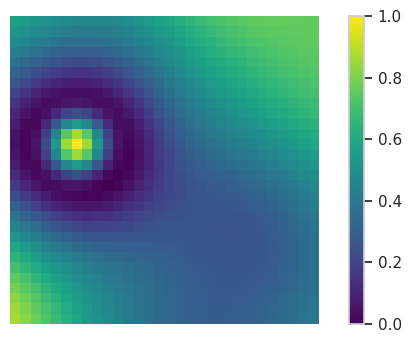

In [95]:
rng = np.random.default_rng(3)
reward, _, _ = make_parent_and_children_correlated_dog(
    rng=rng,
    grid_size=grid_size,
    **reward_params
)
plot_reward_grid(reward)

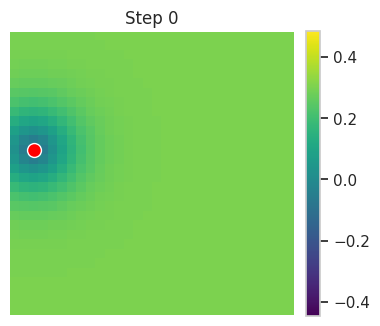

In [96]:
df_batch = pd.DataFrame(batch_results)

heatmaps = df_batch['value'].to_numpy()  # shape (60,), each element is a 2D array
fig, ax = plt.subplots(figsize=(4, 4))

vmin = min(h.min() for h in heatmaps)
vmax = max(h.max() for h in heatmaps)

im = ax.imshow(
    heatmaps[1], cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
)
ax.scatter(df_batch.loc[0, 'choice'][0], df_batch.loc[0, 'choice'][1], color='red', s=100, edgecolor='white')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def update(frame):
    ax.clear()  # Clear previous scatter points
    # im.set_array(heatmaps[frame+1])  # Update the data
    im = ax.imshow(
        heatmaps[frame+1], cmap='viridis', origin='lower', vmin=vmin, vmax=vmax
    )
    ax.scatter(df_batch.loc[frame, 'choice'][1], df_batch.loc[frame, 'choice'][0], color='red', s=100, edgecolor='white')
    ax.set_title(f'Step {frame}')
    ax.axis('off')
    return im,

ani = FuncAnimation(fig, update, frames=len(heatmaps)-1, repeat=False)
ani.save('policy_evolution.gif', writer='pillow', fps=2)

## 3. Explore $\beta$ and $\tau$

In [3]:
rng = np.random.default_rng(42)

grid_size = 20
reward_params = {
    'frequency': 2.5,
    'sigma_inner': 2,
    'sigma_outer': 4,
    'correlation': 1
}
base_lambda = 2
params = {
    "n": [50],
    "grid_size": grid_size,
    "rng": rng,
    "beta": np.arange(0, 0.5, 0.25),
    "length_scale": [base_lambda * 0.5, base_lambda, base_lambda * 1.5, base_lambda * 2, base_lambda * 2.5],
    "tau": np.logspace(-2, -1, num=20),
    "alpha": 0,
    "reward_env_type": 'dog',
    "reward_env_params": [reward_params]
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params,
    max_steps=50,
    display_progress=True,
    data_collection_period=-1,
    number_processes=None
)

  0%|          | 0/200 [00:00<?, ?it/s]

In [11]:
df_batch = pd.DataFrame(batch_results)
df_grouped = df_batch.groupby(['beta', 'length_scale', 'tau']).agg({'mean_reward': 'mean'}).reset_index()

lambdas = df_grouped['length_scale'].unique()
df_lambda =  []
for l in lambdas:
    df_lambda.append(df_grouped[df_grouped['length_scale'] == l])

([<matplotlib.axis.YTick at 0x7f42d453e210>,
 [Text(0, 0, '0.010'),
  Text(0, 1, '0.011'),
  Text(0, 2, '0.013'),
  Text(0, 3, '0.014'),
  Text(0, 4, '0.016'),
  Text(0, 5, '0.018'),
  Text(0, 6, '0.021'),
  Text(0, 7, '0.023'),
  Text(0, 8, '0.026'),
  Text(0, 9, '0.030'),
  Text(0, 10, '0.034'),
  Text(0, 11, '0.038'),
  Text(0, 12, '0.043'),
  Text(0, 13, '0.048'),
  Text(0, 14, '0.055'),
  Text(0, 15, '0.062'),
  Text(0, 16, '0.070'),
  Text(0, 17, '0.078'),
  Text(0, 18, '0.089'),
  Text(0, 19, '0.100')])

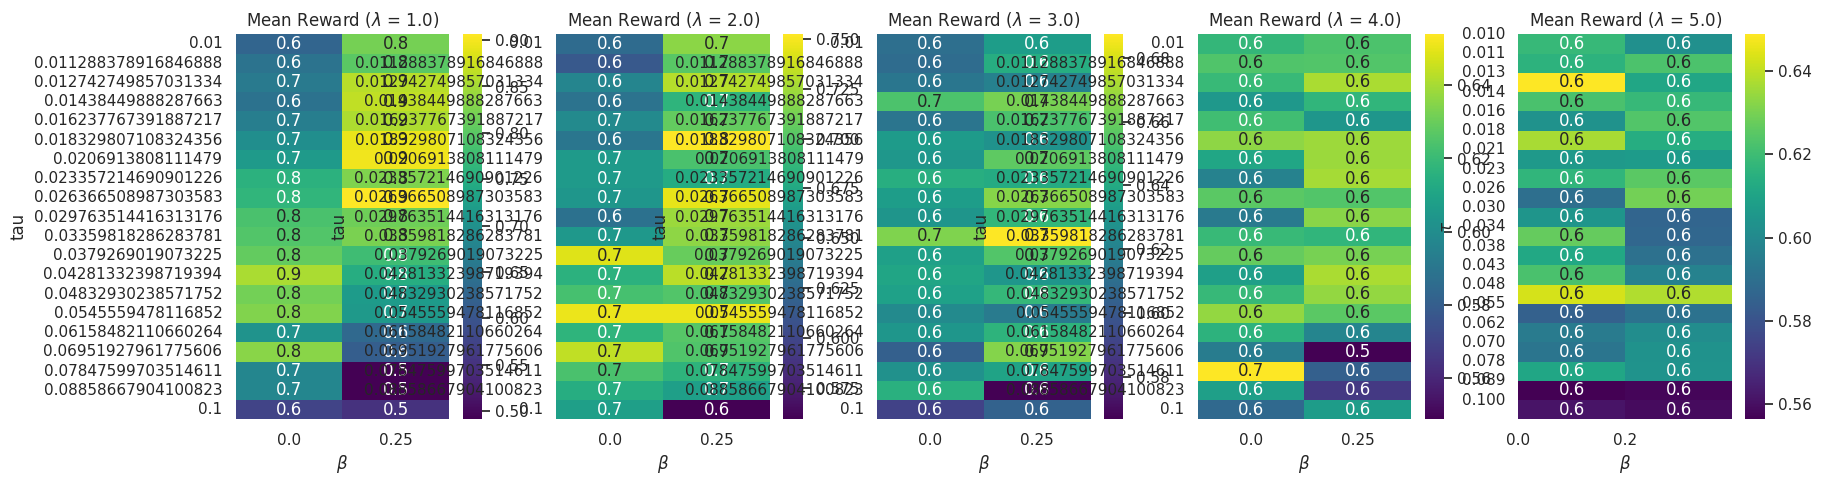

In [15]:
# Plot heatmap for small lambda, x = beta, y = tau, color = mean_reward
plt.figure(figsize=(20, 5))
for i in range(len(df_lambda)):
    plt.subplot(1, 5, i+1)
    pivot_small = df_lambda[i].pivot(index='tau', columns='beta', values='mean_reward')
    sns.heatmap(pivot_small, annot=True, fmt=".1f", cmap='viridis')
    plt.title(r'Mean Reward ($\lambda$ = {})'.format(df_lambda[i]['length_scale'].iloc[0]))
    plt.xlabel(r'$\beta$')
plt.ylabel(r'$\tau$')
# Round numbers for axis ticks
plt.xticks(ticks=np.arange(len(pivot_small.columns)), labels=[f"{b:.1f}" for b in pivot_small.columns])
plt.yticks(ticks=np.arange(len(pivot_small.index)), labels=[f"{t:.3f}" for t in pivot_small.index])